<a href="https://colab.research.google.com/github/thaygorh/Machine-Learning-and-Analytics/blob/main/mvp_machine_learning_and_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP *Machine Learning & Analytics* - Predição de Fluxo de Massa a partir da Corrente de um Motor
**Autor:** Thaygor Henrique Gonçalves  

**Data:** 28/09/2025

**Matrícula:** 4052025000871

**Dataset:**  [Grain Handling Conveyor Operational Data](https://www.kaggle.com/datasets/johanama2018/grain-handling-conveyor-operational-data)

---

## Uso e autoria

Este projeto foi desenvolvido para fins de estudo e portfólio.

O código está disponível para fins educacionais e pode ser utilizado como referência.

Caso utilize este material, por favor, atribua o devido crédito ao autor original:

GitHub: https://github.com/thaygorh/Machine-Learning-and-Analytics

LinkedIn: https://www.linkedin.com/in/thaygorh

## ✅ Checklist do MVP
- [X] **Problema definido e contexto de negócio** → Checklist respondido, definição clara do problema, hipóteses e dataset.  
- [X] **Tratamento dos dados** → Pré-processamento, normalização e tratamento.  
- [X] **Carga e preparação dos dados** → Preservação da ordem dos registros, configuração de features e target.  
- [X] **Divisão em treino/validação/teste** → 90% treino+val / 10% teste holdout.  
- [X] **Modelagem (com baseline)** → Comparação entre DummyRegressor, Ridge, RandomForest, GradientBoosting, LightGBM, CatBoost.  
- [X] **Otimização de hiperparâmetros** → GridSearchCV com validação respeitando a ordem dos registros.  
- [X] **Salvando artefatos** → Salvar e recarregar o melhor modelo, sem precisar retreinar.  
- [X] **Boas práticas** → Seeds fixadas, tempo de treino, documentação em Markdown explicativa, uso de Pipeline.  
- [X] **Avaliação e discussão de limitações** → Holdout (MAE, RMSE, R²), comparação com baseline, curvas de resposta, funções saturantes e híbrida.  
- [X] **Conclusão** → Síntese dos resultados, melhores modelos, limitações e possíveis aplicações práticas.  

---

## 1. Escopo, objetivo e definição do problema

**Contexto do problema e objetivo:**  
Este trabalho tem como objetivo avaliar a viabilidade da predição da taxa de material (lb/s) a partir da corrente elétrica de um motor (A) em um transportador de grãos. Em muitos ambientes industriais, a instalação de balanças pode ser inviável devido a custos, manutenção ou restrições físicas. Dessa forma, busca-se verificar se a corrente pode ser utilizada como alternativa para essa predição, além de identificar qual modelo de aprendizado supervisionado apresenta o melhor desempenho.

**Tipo de tarefa**  
Problema de regressão supervisionada, já que a variável-alvo é contínua (taxa em lb/s).  

**Hipótese**  
Existe relação monotônica crescente, mas não linear, entre a corrente do motor e o fluxo de material transportado, permitindo estimar a vazão.

**Área de aplicação**  
Dados tabulares obtidos a partir de medições de corrente elétrica do motor e de um sistema de pesagem em um transportador de grãos.

**Valor para o negócio/usuário:**  
A solução proposta possibilita reduzir custos com instalação e manutenção de balanças, além de ampliar a disponibilidade da estimativa de taxa em locais onde não é possível realizar a medição direta.

---

## 2. Reprodutibilidade e ambiente

A fim de garantir a reprodutibilidade, o ambiente foi configurado com as seguintes características:

- **Bibliotecas:** NumPy, Pandas, Matplotlib, SciPy, Scikit-learn, LightGBM, CatBoost, Joblib e Requests.  
- **Seed global:** Definida como "42".  
- **Aplicação da seed:** Utilizada nos geradores do NumPy e do Python random para manter consistência.



### 2.1 Dependências

Apenas as bibliotecas adicionais que não fazem parte do ambiente padrão do Google Colab.

In [74]:
!pip install -q lightgbm catboost

### 2.2 Importações e configuração do ambiente

Foram importadas as bibliotecas necessárias para manipulação de dados, visualização, modelagem estatística e machine learning. Também foram incluídos pacotes utilitários para salvar modelos e realizar requisições externas.  

In [75]:
# 2.2 Bibliotecas e Configurações Iniciais

# Configuração para não exibir os warnings
import warnings
warnings.filterwarnings("ignore")

# Utilidades gerais
import os, sys, math, random, time, joblib, requests

# Manipulação de dados
import numpy as np
import pandas as pd

# Visualização
import matplotlib.pyplot as plt

# Modelagem estatística / matemática
from scipy.optimize import curve_fit

# Machine Learning - Scikit-learn
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import Ridge, SGDRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Boosting avançado
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Seed global para reprodutibilidade
SEED = 42
np.random.seed(SEED)
random.seed(SEED)


### 2.3 Funções Python

Funções auxiliares foram criadas para organizar o código:

- **`make_folds`** → gera índices de treino e validação respeitando a ordem dos registros. Essa abordagem evita vazamento de dados entre treino e validação e mantém a consistência da sequência utilizada na modelagem.
- **`sat_with_threshold`** → implementa uma relação saturante com limiar fixo (τ), representando o ponto em que o motor começa efetivamente a transportar material.  
- **`sat_with_exponent`** → versão mais flexível da função anterior, onde o expoente *p* ajusta a curvatura da resposta. Essa generalização permite capturar com maior fidelidade a dinâmica não linear entre corrente e fluxo de massa.  



In [76]:
def make_folds(X, y, n_folds=5):
    """
    Gera índices de treino e validação preservando a ordem dos registros.

    Parâmetros:
    - X : pd.DataFrame ou np.ndarray
        Features.
    - y : pd.Series ou np.ndarray
        Target correspondente.
    - n_folds : int, opcional (default=5)
        Número de divisões utilizadas na validação cruzada.

    Retorna:
    - folds : list of tuples
        Lista de tuplas (train_idx, test_idx).
    """
    block_size = len(X) // n_folds
    folds = []
    for i in range(n_folds):
        start = i * block_size
        end = (i + 1) * block_size
        test_idx = list(range(start, end))
        train_idx = list(range(0, start)) + list(range(end, len(X)))
        folds.append((train_idx, test_idx))
    return folds


def sat_with_threshold(x, A, k, tau_fixed):
    """
    Função saturante com limiar (τ) fixo.

    Propósito:
    Modelar a relação não linear entre corrente do motor e fluxo de massa,
    representando o comportamento em que abaixo de certo limiar (τ) não há
    transporte de material, e acima desse valor a taxa cresce de forma
    assintótica até se estabilizar.

    Fórmula:
    y(x) = 0, se x ≤ τ
    y(x) = A * (1 - exp(-k * (x - τ))), se x > τ

    Parâmetros:
    - x : array-like, entradas (corrente do motor em A)
    - A : float, valor assintótico (taxa máxima estimada)
    - k : float, taxa de crescimento exponencial
    - tau_fixed : float, limiar fixo (τ)

    Retorna:
    - y : array-like, valores previstos
    """
    x = np.asarray(x)
    y = np.zeros_like(x, dtype=float)
    mask = x > tau_fixed
    y[mask] = A * (1.0 - np.exp(-k * (x[mask] - tau_fixed)))
    return y


def sat_with_exponent(x, A, k, p, tau_fixed):
    """
    Função saturante com limiar (τ) fixo e expoente livre.

    Propósito:
    Generalizar a função saturante para ajustar melhor a curvatura da relação
    entre corrente e taxa, permitindo maior flexibilidade no ajuste da curva.

    Fórmula:
    y(x) = 0, se x ≤ τ
    y(x) = A * (1 - exp(-k * (x - τ)^p)), se x > τ

    Parâmetros:
    - x : array-like, entradas (corrente do motor em A)
    - A : float, valor assintótico (taxa máxima estimada)
    - k : float, taxa de crescimento exponencial
    - p : float, expoente de curvatura
    - tau_fixed : float, limiar fixo (τ)

    Retorna:
    - y : array-like, valores previstos
    """
    x = np.asarray(x)
    y = np.zeros_like(x, dtype=float)
    mask = x > tau_fixed
    y[mask] = A * (1.0 - np.exp(-k * np.power(x[mask] - tau_fixed, p)))
    return y


## 3. 3. Entendimento, carga e preparação inicial dos dados

- **Origem dos dados:** O dataset utilizado neste trabalho é público e foi obtido a partir da plataforma Kaggle, disponível em:  
  [Grain Handling Conveyor Operational Data](https://www.kaggle.com/datasets/johanama2018/grain-handling-conveyor-operational-data)
- **Aspectos éticos e confidencialidade:** Trata-se de um dataset público, não havendo restrições de confidencialidade associadas aos dados utilizados neste estudo.  
- **Dicionário de variáveis:**  
  - **Corrente do Motor (A):** Corrente elétrica em amperes, utilizada como variável de entrada (X).  
  - **Taxa da Balança (lb/s):** Fluxo de massa transportado na correia, estimado por sistema de pesagem, definido como variável-alvo.  
- **Qualidade e pré-processamento:** O dataset utilizado neste trabalho passou por um tratamento prévio antes de sua utilização, sendo posteriormente disponibilizado no repositório do projeto.  
   - Foi realizado o ajuste do padrão numérico, substituindo a vírgula por ponto como separador decimal.
  - O valor da balança foi previamente defasado em planilha (Excel), devido à maior praticidade na identificação do deslocamento temporal correto.
  - Não há valores nulos no conjunto de dados.
  - Foi realizada a padronização dos nomes das colunas em `snake_case`.



In [77]:
# Carga e verificação inicial dos dados

# Carregar dataset
df = pd.read_csv(
    "https://raw.githubusercontent.com/thaygorh/Machine-Learning-and-Analytics/refs/heads/main/Grain-Handling-Conveyor-Operational-Data-tratados.csv",
    sep=";"
)

# Converter vírgula decimal para ponto em colunas numéricas
for col in df.columns:
    if df[col].dtype == object:
        try:
            df[col] = df[col].astype(str).str.replace(",", ".", regex=False).astype(float)
        except ValueError:
            pass

# Renomear colunas para snake_case
df = df.rename(columns=lambda x: x.strip().lower().replace(" ", "_"))

# Resetar índice
df = df.reset_index(drop=True)

# Exibir amostras e informações básicas
display(df.head())
print("\nFormato:", df.shape)
print("\nTipos de dados:\n", df.dtypes)
print("\nValores ausentes por coluna:\n", df.isna().sum())


,corrente_do_motor,taxa_da_balanca
0,7.857,0.0
1,7.857,0.0
2,7.857,0.0
3,7.857,0.0
4,7.857,0.0



Formato: (12518, 2)

Tipos de dados:
 corrente_do_motor    float64
taxa_da_balanca      float64
dtype: object

Valores ausentes por coluna:
 corrente_do_motor    0
taxa_da_balanca      0
dtype: int64


## 3.1 Análise exploratória dos dados (EDA)

Nesta etapa foi realizada uma análise exploratória inicial para compreender a relação entre a corrente elétrica do motor e a taxa registrada pela balança de grãos.

Observações preliminares:

- As variáveis **corrente_do_motor** e **taxa_da_balanca** apresentam comportamento correlacionado, indicando que a corrente pode ser utilizada como variável preditora da taxa.
- A relação entre as variáveis não é perfeitamente linear, mas a regressão simples permite visualizar a tendência geral dos dados.
- Valores de corrente próximos ao mínimo observado parecem estar associados ao motor ligado sem passagem significativa de material, com taxa próxima de zero.
- A dispersão dos pontos sugere que, além da tendência geral, existem variações operacionais que podem influenciar a taxa registrada.

O gráfico de dispersão permite visualizar a distribuição dos dados entre corrente do motor e taxa da balança. A linha de regressão simples foi adicionada apenas como apoio visual para identificar a tendência geral da relação, sem representar ainda o modelo final do projeto.

,corrente_do_motor,taxa_da_balanca
count,12518.000000,12518.000000
mean,13.605392,46.513952
std,4.883013,30.617206
min,0.000000,0.000000
25%,8.514000,14.647495
50%,14.714000,58.709031
75%,17.343000,72.073437
max,29.257000,102.289959


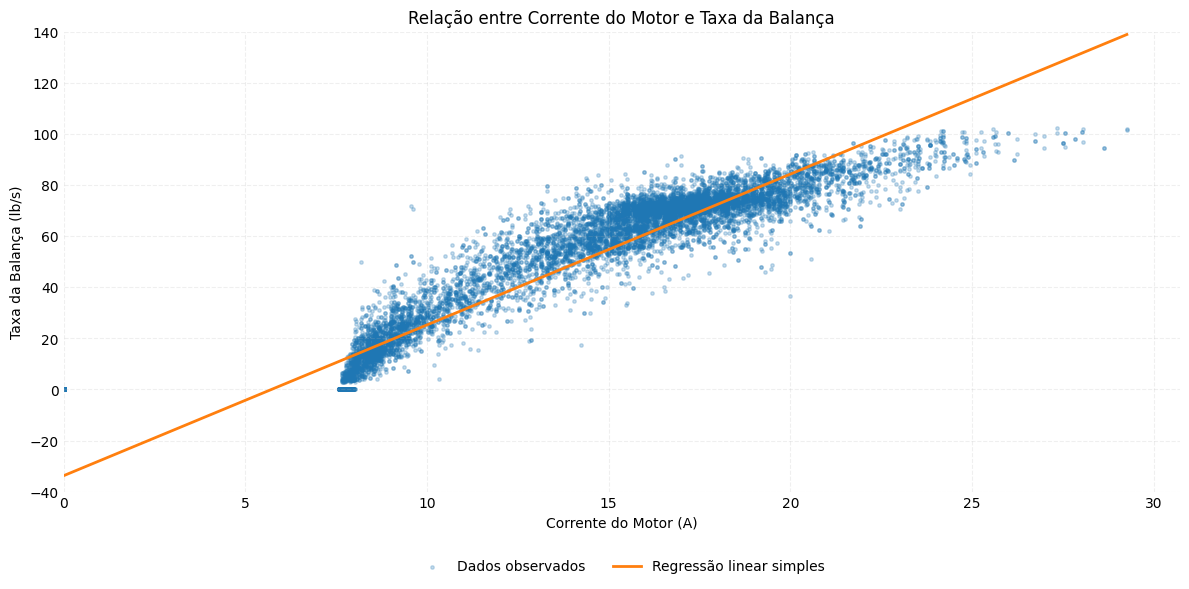

In [78]:
# Estatísticas descritivas
display(df.describe())

# Gráfico de dispersão: taxa da balança (y) vs corrente do motor (x)
fig, ax = plt.subplots(figsize=(12, 6))

ax.scatter(
    df["corrente_do_motor"],
    df["taxa_da_balanca"],
    alpha=0.25,
    s=6,
    label="Dados observados"
)

# Regressão simples para visualização da tendência geral
coef = np.polyfit(
    df["corrente_do_motor"],
    df["taxa_da_balanca"],
    deg=1
)

linha_regressao = np.poly1d(coef)

x_linha = np.linspace(
    df["corrente_do_motor"].min(),
    df["corrente_do_motor"].max(),
    200
)

y_linha = linha_regressao(x_linha)

ax.plot(
    x_linha,
    y_linha,
    color="tab:orange",
    linewidth=2,
    label="Regressão linear simples"
)

# Formatação do gráfico
ax.set_title("Relação entre Corrente do Motor e Taxa da Balança")
ax.set_xlabel("Corrente do Motor (A)")
ax.set_ylabel("Taxa da Balança (lb/s)")

# Limites dos eixos
ax.set_xlim(left=0)
ax.set_ylim(-40, 140)

# Grade
ax.grid(True, linestyle="--", alpha=0.2)

# Remover bordas pretas do gráfico
for spine in ax.spines.values():
    spine.set_visible(False)

# Manter apenas marcações dos eixos
ax.tick_params(axis="both", length=0)

# Legenda inferior
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=2,
    frameon=False
)

plt.tight_layout()
plt.show()

## 4. Definição do target, variáveis e divisão dos dados

- **Target (variável-alvo):** `taxa_da_balanca` (lb/s).  
- **Variável preditora:** `corrente_do_motor` (A).  

- **Divisão dos dados:**  
  - Os primeiros **90% das amostras** são usados para treino e validação, aplicando validação cruzada em 5 blocos de tamanho igual.
  - Os últimos **10% das amostras** formam o conjunto **holdout**, reservado exclusivamente para a avaliação final.

- **Observação:** A divisão dos dados respeita a ordem dos registros, evitando vazamento de informação entre treino e avaliação. O conjunto holdout permanece reservado exclusivamente para a validação final dos modelos.


In [79]:
# Definição do problema e divisão dos dados

PROBLEM_TYPE = "regressao"

# Target e feature
target = "taxa_da_balanca"
feature_cols = ["corrente_do_motor"]

X_all = df[feature_cols].copy()
y_all = df[target].copy()

# Separação em treino/validação (CV) e holdout final
holdout_size = int(len(X_all) * 0.1)  # últimos 10% dos dados
split_point = len(X_all) - holdout_size

X_cv, y_cv = X_all.iloc[:split_point], y_all.iloc[:split_point]
X_holdout, y_holdout = X_all.iloc[split_point:], y_all.iloc[split_point:]

# Criar folds usando função definida no tópico 2.3
folds = make_folds(X_cv, y_cv, n_folds=5)

# Resumo
print(f"PROBLEM_TYPE: {PROBLEM_TYPE}")
print(f"Target: {target}")
print(f"N features: {X_all.shape[1]}")
print(f"Treino + Validação (Cross-Validation): {X_cv.shape}")
print(f"Holdout final: {X_holdout.shape}\n")

print("Validação cruzada respeitando a ordem dos registros (5 folds):")
for i, (train_idx, test_idx) in enumerate(folds, 1):
    print(f" - Fold {i}: Validação = amostras {test_idx[0]}–{test_idx[-1]} | Treino = restante")

PROBLEM_TYPE: regressao
Target: taxa_da_balanca
N features: 1
Treino + Validação (Cross-Validation): (11267, 1)
Holdout final: (1251, 1)

Validação cruzada respeitando a ordem dos registros (5 folds):
 - Fold 1: Validação = amostras 0–2252 | Treino = restante
 - Fold 2: Validação = amostras 2253–4505 | Treino = restante
 - Fold 3: Validação = amostras 4506–6758 | Treino = restante
 - Fold 4: Validação = amostras 6759–9011 | Treino = restante
 - Fold 5: Validação = amostras 9012–11264 | Treino = restante


## 5. Pré-processamento e pipeline de transformação  

Foram definidos dois pré-processadores para avaliar o impacto da padronização no desempenho dos modelos:

- **Raw (sem padronização):** utiliza os dados brutos diretamente.  
- **Scaled (com padronização):** aplica `StandardScaler` sobre a variável preditora.  

Essa abordagem permite comparar se a padronização traz ganhos relevantes para o ajuste dos modelos, especialmente em algoritmos sensíveis à escala dos dados, como regressão linear e métodos baseados em gradiente. Além disso, o scaler é ajustado apenas nos dados de treino.




In [80]:
# Tratamento de dados e pré-processamento

# Pré-processamento sem padronização (dados brutos)
preprocess_raw = ColumnTransformer(
    transformers=[("pass", "passthrough", feature_cols)],
    remainder="drop"
)

# Pré-processamento com padronização (StandardScaler)
preprocess_scaled = ColumnTransformer(
    transformers=[("scale", StandardScaler(), feature_cols)],
    remainder="drop"
)

print("Pré-processadores definidos:")
print(" - Raw (sem padronização)")
print(" - Scaled (com StandardScaler)")


Pré-processadores definidos:
 - Raw (sem padronização)
 - Scaled (com StandardScaler)


## 6. Baseline e modelos candidatos  

Foi utilizado um **DummyRegressor** como baseline, que prevê sempre a média dos valores de treino. Esse baseline define o limite inferior de desempenho: os modelos precisam superá-lo para demonstrar que realmente capturam padrões nos dados, e não apenas reproduzem estimativas.

Modelos selecionados para comparação:  
- **Ridge Regression** → regressão linear com regularização L2: verificar se uma abordagem linear consegue capturar parte da relação entre corrente e taxa.  
- **Random Forest Regressor** → conjunto de árvores de decisão: robusto para capturar não linearidades sem necessidade de grande pré-processamento.  
- **Gradient Boosting Regressor** → boosting sequencial de árvores: tende a ajustar melhor padrões complexos.  
- **SGD Regressor** → regressão linear otimizada por descida de gradiente: eficiente em bases maiores, podendo apresentar limitações em relações fortemente não lineares.  
- **LightGBM** → variante otimizada de gradient boosting: projetada para velocidade e escalabilidade.  
- **CatBoost** → algoritmo de boosting eficiente para dados tabulares: conhecido por bom desempenho consistente e simplicidade de uso.  

Cada modelo foi avaliado em duas versões:  
- **Raw** (dados sem normalização)  
- **Scaled** (dados normalizados com `StandardScaler`)  

A diversidade de modelos permite comparar soluções lineares simples até algoritmos mais sofisticados de ensemble.  


In [81]:
# Baseline e modelos candidatos

# Função de avaliação
def eval_reg(y_true, y_pred, label=''):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    return dict(Modelo=label, MAE=mae, RMSE=rmse, R2=r2)

# Função para grid search
def run_grid(pipe, params, Xtr, ytr):
    t0 = time.time()
    gs = GridSearchCV(
        pipe,
        params,
        scoring="neg_mean_absolute_error",
        cv=5,
        n_jobs=-1,
        verbose=0
    )
    gs.fit(Xtr, ytr)
    elapsed = time.time() - t0
    return gs, elapsed

# Definição dos modelos candidatos
models = {
    "Baseline": None,

    "Ridge": (Pipeline([
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('reg', Ridge())
    ]), {
        'poly__degree': [1, 2],
        'reg__alpha': [0.1, 1.0, 10.0]
    }),

    "RandomForest": (Pipeline([
        ('rf', RandomForestRegressor(random_state=SEED))
    ]), {
        'rf__n_estimators': [200, 400],
        'rf__max_depth': [None, 15, 25]
    }),

    "GradientBoosting": (Pipeline([
        ('gb', GradientBoostingRegressor(random_state=SEED))
    ]), {
        'gb__n_estimators': [200, 400],
        'gb__learning_rate': [0.05, 0.1]
    }),

    "SGDRegressor": (Pipeline([
        ('sgd', SGDRegressor(random_state=SEED, max_iter=1000))
    ]), {
        'sgd__alpha': [0.0001, 0.001],
        'sgd__penalty': ['l2', 'l1']
    }),

    "LightGBM": (Pipeline([
        ('lgbm', LGBMRegressor(
            random_state=SEED,
            verbosity=-1   # logs: -1 (sem logs), 0 (erros), 1 (info), >1 (debug detalhado)
        ))
    ]), {
        'lgbm__n_estimators': [200, 400],
        'lgbm__learning_rate': [0.05, 0.1],
        'lgbm__max_depth': [-1, 15, 25]
    }),

    "CatBoost": (Pipeline([
        ('cat', CatBoostRegressor(
            random_state=SEED,
            verbose=0   # logs: 0 (sem saída), >0 imprime a cada N iterações
        ))
    ]), {
        'cat__iterations': [200, 400],
        'cat__learning_rate': [0.05, 0.1],
        'cat__depth': [6, 10]
    })
}


## 7. Validação, Otimização e Resultados  

Os modelos foram treinados e avaliados por meio de validação cruzada em **5 folds**, respeitando a ordem dos registros.
O ajuste de hiperparâmetros foi feito com **GridSearchCV** em cada fold, garantindo que o processo de treino fosse sistemático e comparável.  

#### Métricas utilizadas  
- **MAE (Mean Absolute Error):** erro absoluto médio.  
- **RMSE (Root Mean Squared Error):** erro quadrático médio, mais sensível a outliers.  
- **R² (Coeficiente de Determinação):** proporção da variância explicada pelo modelo.  

Para cada modelo, foram calculadas as métricas em cada fold.  
Os resultados exibidos correspondem à **média dos 5 folds**, acompanhados do **desvio-padrão (± std)**.  

#### Interpretação  
- A **média** mostra o desempenho esperado do modelo.  
- O **desvio-padrão** indica a estabilidade:  
  - Valores baixos → desempenho consistente entre os folds.  
  - Valores altos → maior variação de desempenho entre os folds.   

O Baseline (`DummyRegressor`) não realiza treinamento, retorna apenas a média do treino como predição.
Todas as métricas do baseline foram muito ruins em comparação com os outros modelos, confirmando que a simples média dos valores de treino não seria aplicável em um caso real.  

#### Observação sobre o processo  
Para evitar repetir todo o processo de treino sempre que o notebook for executado, foi incluída a opção de **force_retrain**.  
Por padrão, a variável `force_retrain` está como `False`, mas pode ser alterada para `True` caso seja necessário treinar novamente.  


In [82]:
# 7. Validação, Otimização e Resultados

force_retrain = False  # Coloque True se quiser executar novamente toda a validação

model_url = "https://raw.githubusercontent.com/thaygorh/Machine-Learning-and-Analytics/556eba94cf879c413061cec17e4e6a5048e6335a/best_model.pkl"
model_path = "best_model.pkl"

if not force_retrain:
    try:
        print("Baixando best_model.pkl do GitHub...")

        r = requests.get(model_url)
        r.raise_for_status()

        with open(model_path, "wb") as f:
            f.write(r.content)

        df_cv_mean, best_model = joblib.load(model_path)

        print("Melhor modelo carregado do arquivo salvo")

    except Exception as e:
        print("Falha ao carregar do GitHub, treinando novamente...", e)
        force_retrain = True

if force_retrain:
    print("Executando validação cruzada completa...")

    results = []

    # Loop para versões Raw e Scaled
    for prep_name, prep in [
        ("Raw", preprocess_raw),
        ("Scaled", preprocess_scaled)
    ]:

        for name, cfg in models.items():

            # Baseline
            if name == "Baseline":

                for i, (train_idx, test_idx) in enumerate(folds, 1):

                    y_train = y_cv.iloc[train_idx]
                    y_test = y_cv.iloc[test_idx]

                    y_pred = np.full_like(
                        y_test.values,
                        y_train.mean(),
                        dtype=float
                    )

                    rec = eval_reg(
                        y_test,
                        y_pred,
                        label=f"{name}_{prep_name}_Fold{i}"
                    )

                    rec["TrainTime_s"] = 0.0

                    results.append(rec)

            # Demais modelos
            else:

                pipe, grid = cfg

                steps = [('prep', prep)] + pipe.steps
                pipe = Pipeline(steps)

                for i, (train_idx, test_idx) in enumerate(folds, 1):

                    X_train = X_cv.iloc[train_idx]
                    y_train = y_cv.iloc[train_idx]

                    X_test = X_cv.iloc[test_idx]
                    y_test = y_cv.iloc[test_idx]

                    gs, dt = run_grid(
                        pipe,
                        grid,
                        X_train,
                        y_train
                    )

                    y_pred = gs.predict(X_test)

                    rec = eval_reg(
                        y_test,
                        y_pred,
                        label=f"{name}_{prep_name}_Fold{i}"
                    )

                    rec["TrainTime_s"] = dt

                    results.append(rec)

    # Consolidar resultados
    df_results = pd.DataFrame(results)

    df_results["Modelo_Base"] = (
        df_results["Modelo"]
        .str.replace(r"_Fold\d+", "", regex=True)
    )

    # Estatísticas agregadas
    df_cv_mean = (
        df_results
        .groupby("Modelo_Base")
        .agg({
            "MAE": ["mean", "std"],
            "RMSE": ["mean", "std"],
            "R2": ["mean", "std"],
            "TrainTime_s": "sum"
        })
        .reset_index()
    )

    # Renomear colunas
    df_cv_mean.columns = [
        "Modelo_Base",
        "MAE_mean", "MAE_std",
        "RMSE_mean", "RMSE_std",
        "R2_mean", "R2_std",
        "TrainTime_total"
    ]

    # Ordenar pelo melhor R²
    df_cv_mean = df_cv_mean.sort_values(
        by="R2_mean",
        ascending=False
    )

    best_model = df_cv_mean.iloc[0]

    print(
        f"\nMelhor desempenho médio: "
        f"{best_model['Modelo_Base']} "
        f"(R² = {best_model['R2_mean']:.4f} "
        f"± {best_model['R2_std']:.4f})\n"
    )

    # Salvar resultados
    joblib.dump(
        (df_cv_mean, best_model),
        model_path
    )

# Exibir tabela final
df_cv_mean

Baixando best_model.pkl do GitHub...
Melhor modelo carregado do arquivo salvo


,Modelo_Base,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std,TrainTime_total
3,CatBoost_Scaled,4.023380,1.037848,5.799736,1.289948,0.963039,0.016702,90.770767
2,CatBoost_Raw,4.026949,1.034291,5.802073,1.287556,0.963016,0.016678,117.886543
5,GradientBoosting_Scaled,4.030463,1.017738,5.826138,1.283407,0.962736,0.016760,9.187104
4,GradientBoosting_Raw,4.030495,1.017755,5.826407,1.283532,0.962732,0.016760,9.188999
6,LightGBM_Raw,4.072378,0.995132,5.875717,1.260432,0.962176,0.016684,26.397560
7,LightGBM_Scaled,4.090451,1.014360,5.908640,1.278478,0.961712,0.017108,24.160331
9,RandomForest_Scaled,4.317984,1.040816,6.260597,1.324738,0.957087,0.018814,25.121567
8,RandomForest_Raw,4.319841,1.041549,6.264590,1.325122,0.957036,0.018807,27.010557
13,SGDRegressor_Scaled,8.522709,1.114233,10.635332,1.962420,0.877072,0.050748,0.300400
12,SGDRegressor_Raw,8.570027,1.261620,10.696003,2.031766,0.875566,0.052118,0.345289


## 8. Avaliação final e aproximação matemática do modelo  

O melhor modelo, selecionado na validação cruzada, foi o **CatBoost**.  
Ele foi re-treinado em **todo o conjunto de treino/validação (90% dos dados)** e avaliado no **holdout (10%)**, que permaneceu separado durante o processo.  

Esse conjunto funciona como um **teste final**, representando um cenário mais próximo da aplicação em produção e permitindo avaliar a capacidade de generalização em dados nunca vistos.  

As métricas finais consideradas foram: **MAE, RMSE e R²**.  

#### Resultados Observados  
- A comparação com o **DummyRegressor (baseline)** evidencia o ganho real do modelo sobre uma estratégia simples baseada na média.  
- O uso do holdout garante avaliação imparcial. Apesar do R² no holdout ter sido de **0.9**, ligeiramente abaixo do valor observado no treino/validação (**0.96**), o resultado ainda é muito satisfatório.

### Limitações

- O modelo utiliza apenas a variável `corrente_do_motor`, portanto não considera outras condições que podem influenciar a taxa, como tipo de grão, umidade, entre outros fatores operacionais.
- Quando se utiliza a taxa da balança como referência para o treinamento, a qualidade do modelo depende diretamente da consistência dessa medição.
- A aplicação em outros transportadores, materiais ou condições de processo diferentes irá exigir nova validação e re-treinamento do modelo.

In [83]:
# 8. Avaliação final no Holdout

print("Treinando novamente o melhor modelo no conjunto treino/validação...")

best_model_name = best_model["Modelo_Base"]

# Identificar se Raw ou Scaled
prep_type = "Raw" if "Raw" in best_model_name else "Scaled"
prep = preprocess_raw if prep_type == "Raw" else preprocess_scaled

# Nome base do modelo
base_name = best_model_name.replace("_Raw", "").replace("_Scaled", "")
pipe, grid = models[base_name]

steps = [('prep', prep)] + pipe.steps
pipe = Pipeline(steps)

# Treinar com todo o treino+validação (90% dos dados)
gs = GridSearchCV(pipe, grid, scoring='r2', cv=5, n_jobs=-1, verbose=0)
gs.fit(X_cv, y_cv)

print("Treinamento concluído! Avaliando no holdout...")

# Avaliação no Holdout
y_pred_holdout = gs.predict(X_holdout)
rec_best = eval_reg(y_holdout, y_pred_holdout, label=f"{best_model_name}_Holdout")

# Baseline no Holdout
y_pred_baseline = np.full_like(y_holdout.values, y_cv.mean(), dtype=float)
rec_base = eval_reg(y_holdout, y_pred_baseline, label="Baseline_Holdout")

# DataFrame comparando Baseline vs Melhor Modelo
df_holdout = (
    pd.DataFrame([rec_base, rec_best])
    .round(4)
    .rename(columns={
        "Modelo": "Modelo",
        "MAE": "MAE_holdout",
        "RMSE": "RMSE_holdout",
        "R2": "R2_holdout"
    })
)

display(df_holdout)


Treinando novamente o melhor modelo no conjunto treino/validação...
Treinamento concluído! Avaliando no holdout...


,Modelo,MAE_holdout,RMSE_holdout,R2_holdout
0,Baseline_Holdout,22.4734,25.7516,-0.2451
1,CatBoost_Scaled_Holdout,5.5610,7.1511,0.9040


### 8.1 Visualização das previsões no Holdout  

Para complementar a análise, foi criada uma visualização das séries temporais no conjunto holdout.

O gráfico compara diretamente:  

- **Taxa da Balança (lb/s)** — valores reais registrados pela balança e retirados do dataset.  
- **Predição da Taxa (lb/s)** — valores estimados pelo modelo selecionado (**CatBoost**).  
- **Corrente do Motor (A)** — exibida no eixo secundário apenas como referência contextual.

#### Interpretação  
- De modo geral, o modelo reproduz de forma consistente o comportamento da taxa registrada pela balança ao longo do tempo.

- As maiores diferenças entre valor real e previsto ocorrem em variações rápidas da taxa, onde a resposta do modelo tende a apresentar comportamento mais suavizado.

- Ainda assim, o alinhamento entre as curvas indica que o modelo capturou bem a relação entre corrente do motor e a taxa de grãos transportados.



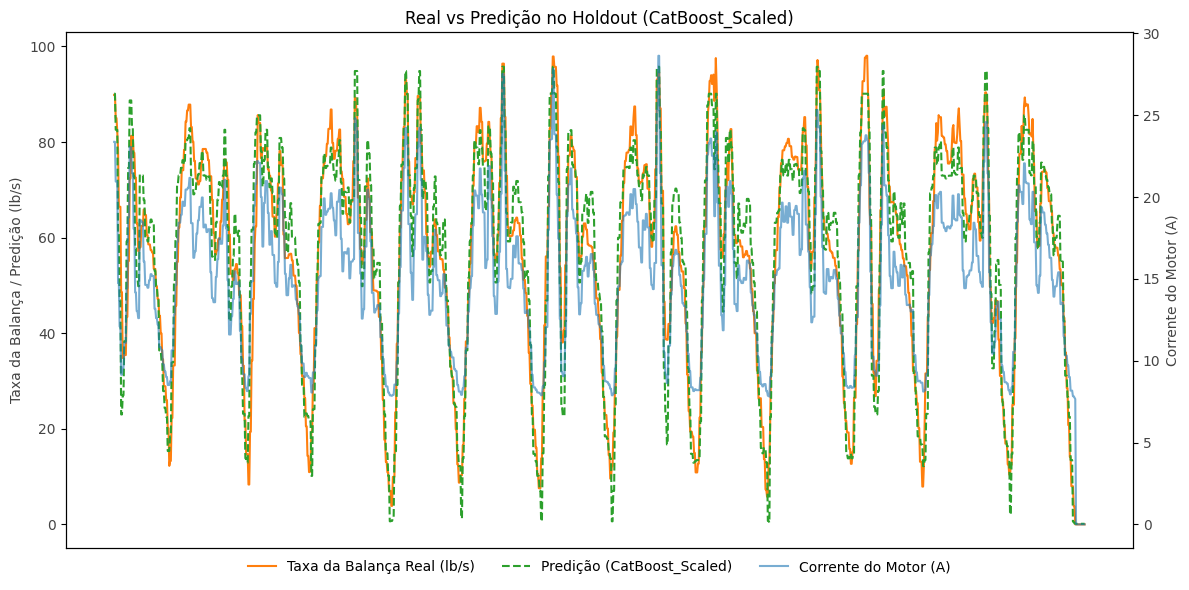

In [84]:
# 8.1 Visualização das previsões (Holdout)

plt.figure(figsize=(12, 6))
ax1 = plt.gca()

# Taxa da Balança real
ax1.plot(y_holdout.index, y_holdout.values, color='tab:orange', label='Taxa da Balança Real (lb/s)')

# Predição do modelo selecionado
ax1.plot(
    y_holdout.index, y_pred_holdout,
    color='tab:green', linestyle='--',
    label=f'Predição ({best_model["Modelo_Base"]})'
)

ax1.set_xlabel('')
ax1.set_xticks([])
ax1.set_ylabel('Taxa da Balança / Predição (lb/s)', color='#444444')
ax1.tick_params(axis='y', labelcolor='#444444')

# Corrente do Motor no eixo secundário (referência)
ax2 = ax1.twinx()
ax2.plot(X_holdout.index, X_holdout['corrente_do_motor'], color='tab:blue', alpha=0.6, label='Corrente do Motor (A)')
ax2.set_ylabel('Corrente do Motor (A)', color='#444444')
ax2.tick_params(axis='y', labelcolor='#444444')

# Título e legenda
plt.title(f'Real vs Predição no Holdout ({best_model["Modelo_Base"]})')

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
plt.legend(
    lines_1 + lines_2, labels_1 + labels_2,
    loc='upper center', bbox_to_anchor=(0.5, 0), ncol=3, frameon=False
)

plt.tight_layout()
plt.show()


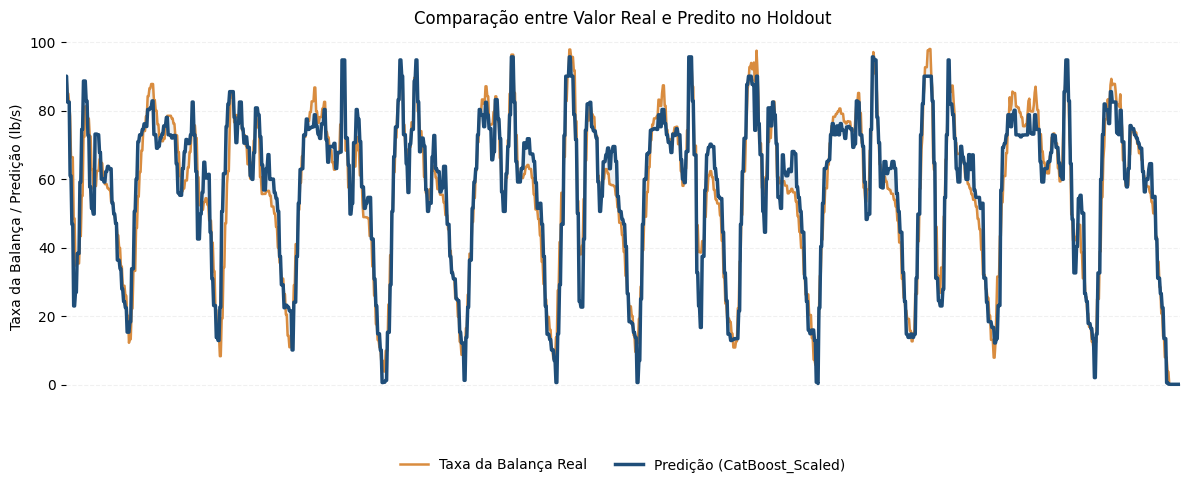

In [101]:
# Comparação com área sombreada de erro

plt.figure(figsize=(12, 5))
ax = plt.gca()

# Taxa real
ax.plot(
    y_holdout.index,
    y_holdout.values,
    color="#D98C3F",
    linewidth=1.8,
    label="Taxa da Balança Real"
)

# Predição
ax.plot(
    y_holdout.index,
    y_pred_holdout,
    color="#1F4E79",
    linewidth=2.5,
    label=f"Predição ({best_model_name})"
)

# Área do erro
ax.fill_between(
    y_holdout.index,
    y_holdout.values,
    y_pred_holdout,
    color="#1F4E79",
    alpha=0.08
)

# Remover bordas
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)

ax.margins(x=0)

ax.set_xlabel("")
ax.set_xticks([])
ax.set_ylabel("Taxa da Balança / Predição (lb/s)")

plt.title("Comparação entre Valor Real e Predito no Holdout")

plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=2,
    frameon=False
)

plt.grid(True, linestyle="--", alpha=0.18)

plt.tight_layout()
plt.show()

### 8.2 Curva de resposta do modelo  

Para analisar o comportamento do modelo selecionado, foi simulada uma série de correntes variando de **0,0 a 30,0 A**, em passos de **0,01 A**.  

O modelo previu a **Taxa da Balança (lb/s)** para cada valor dessa faixa, resultando em uma curva de resposta que mostra como ele aprendeu a relacionar a corrente do motor com a taxa prevista.

#### **Interpretação**
- A curva indica uma relação crescente entre a corrente do motor e a taxa prevista pela balança.

- Em correntes mais baixas, próximas ao início da faixa simulada, o modelo prevê taxa próxima de zero, comportamento coerente onde não ocorre passagem de grãos pela transportadora.

- Conforme a corrente aumenta, a predição da taxa também cresce, indicando que o modelo conseguiu capturar a relação entre o esforço do motor e o fluxo de grãos transportados.

- As previsões fora da faixa operacional, como nas faixas mais elevadas de corrente, devem ser interpretadas com cautela, pois representam regiões com menor disponibilidade de dados para treinamento.

- Essa análise será utilizada no tópico seguinte ao criar uma **função matemática** como forma alternativa de representação, permitindo avaliar se essa aproximação consegue capturar o mesmo comportamento observado no modelo treinado.


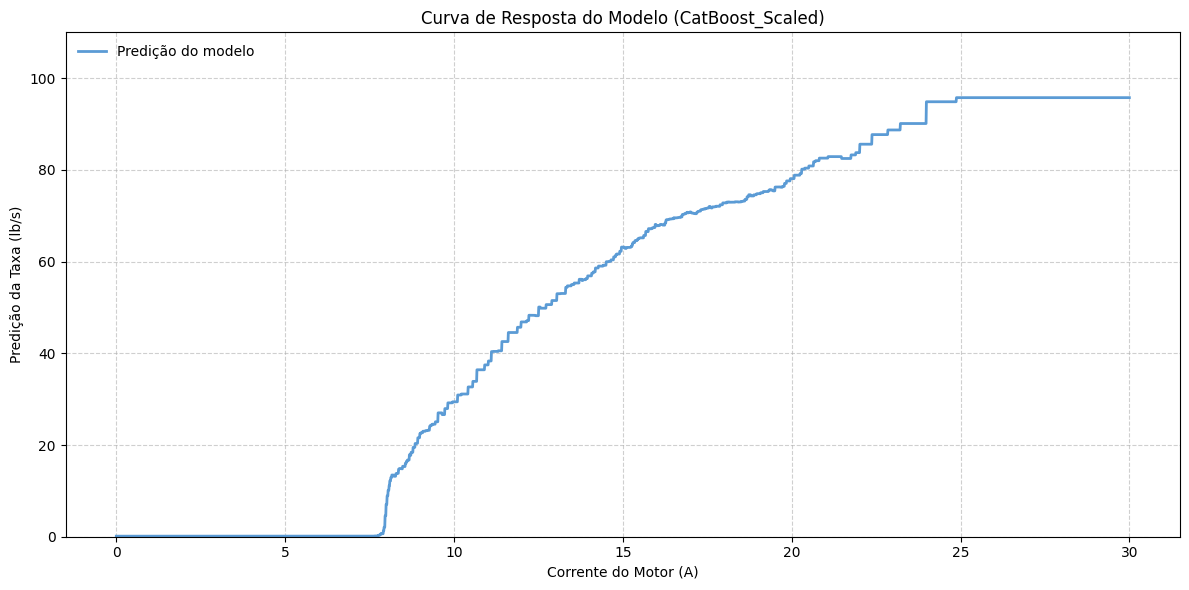

In [94]:
# 8.2 Curva de resposta do modelo

# Geração de correntes simuladas
corrente_simulada = np.arange(0, 30.01, 0.01)
X_simulado = pd.DataFrame(corrente_simulada, columns=["corrente_do_motor"])

# Predição do modelo treinado
y_pred_simulada = gs.predict(X_simulado)

# Gráfico da curva de resposta
plt.figure(figsize=(12, 6))

plt.plot(
    X_simulado["corrente_do_motor"],
    y_pred_simulada,
    color="#5B9BD5",
    linewidth=2,
    label="Predição do modelo"
)

plt.xlabel("Corrente do Motor (A)")
plt.ylabel("Predição da Taxa (lb/s)")
plt.title(f"Curva de Resposta do Modelo ({best_model_name})")

plt.ylim(0, 110)

plt.legend(loc="upper left", frameon=False)

plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

### 8.3 Ajuste da função saturante global

A partir da curva de resposta (Tópico 8.2), foi realizado o ajuste de uma **função saturante** (`sat_with_exponent` no código) para avaliar se a relação entre corrente e taxa pode ser representada de forma mais simples.  

A ideia é que, abaixo de um determinado **limiar físico (τ)**, a taxa prevista seja próxima de zero, indicando condição sem passagem significativa de grãos. Acima desse limiar, a taxa cresce conforme o aumento da corrente do motor, até entrar em uma região de saturação.

#### **Etapas**
1. Foi considerada a faixa de **0 a 30 A**.  
2. Definiu-se um **limiar fixo (τ = 7,9 A)** com base no ponto de subida do gráfico.  
3. Os parâmetros **A** (valor assintótico máximo), **k** (taxa de crescimento) e **p** (expoente de curvatura) foram ajustados automaticamente com `curve_fit`.  
4. A função ajustada foi então comparada com as predições do modelo para verificar se mantém uma forma coerente e interpretável.  

#### **Fórmula matemática**

- y(x) = 0, se x ≤ τ  
- y(x) = A * (1 - exp(-k * (x - τ)^p)), se x > τ

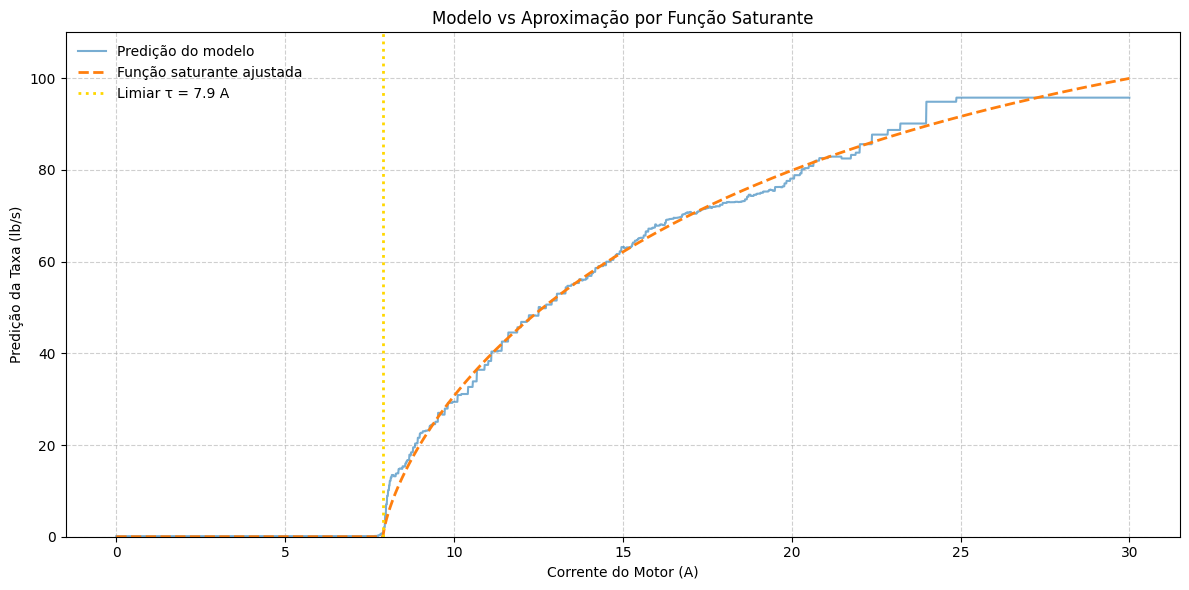

Função ajustada (x em A, y em lb/s):
f(x) = 0, se x ≤ 7.9
f(x) = 128.58 * (1 - exp(-0.1593 * (x - 7.9)^0.72)), se x > 7.9


In [87]:
# 8.3 Ajuste de função saturante (Global)

# 1) Simulação de corrente na faixa analisada
x = np.arange(0, 30.01, 0.01)
X_sim = pd.DataFrame({"corrente_do_motor": x})
y_model = gs.predict(X_sim)

# 2) Definição do limiar físico
tau = 7.9  # limiar físico aproximado (A)

# 3) Ajuste dos parâmetros A, k e p usando curve_fit
mask_fit = x > tau
x_fit, y_fit = x[mask_fit], y_model[mask_fit]

# Chutes iniciais
A0 = np.nanpercentile(y_fit, 95) if len(y_fit) else 100.0
k0, p0 = 0.05, 0.8

popt, _ = curve_fit(
    lambda xv, A, k, p: sat_with_exponent(xv, A, k, p, tau),
    x_fit, y_fit,
    p0=[A0, k0, p0],
    bounds=([0, 0, 0.1], [np.inf, np.inf, 2.0]),
    maxfev=20000
)

A_hat, k_hat, p_hat = popt

# 4) Predição da função ajustada
y_fun = sat_with_exponent(x, A_hat, k_hat, p_hat, tau)

# 5) Comparação gráfica
plt.figure(figsize=(12, 6))

plt.plot(x, y_model, alpha=0.6, label="Predição do modelo")
plt.plot(
    x, y_fun,
    linestyle="--",
    linewidth=2,
    label="Função saturante ajustada"
)

plt.axvline(
    tau,
    color="gold",
    linestyle=":",
    linewidth=2,
    label=f"Limiar τ = {tau:.1f} A"
)

plt.xlabel("Corrente do Motor (A)")
plt.ylabel("Predição da Taxa (lb/s)")
plt.title("Modelo vs Aproximação por Função Saturante")

plt.ylim(0, 110)

plt.legend(loc="upper left", frameon=False)
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

# 6) Exibir fórmula final
print("Função ajustada (x em A, y em lb/s):")
print(f"f(x) = 0, se x ≤ {tau:.1f}")
print(f"f(x) = {A_hat:.2f} * (1 - exp(-{k_hat:.4f} * (x - {tau:.1f})^{p_hat:.2f})), se x > {tau:.1f}")

### 8.4 Ajuste da função saturante local  

No Tópico 8.3 foi ajustada a curva global até **30 A**, mas a **subida inicial (7,9 A a 8,4 A)** não foi representada com precisão.  

Para capturar melhor esse comportamento inicial, foi ajustada uma função saturante restrita a esse intervalo, permitindo representar de forma mais fiel a **curva de crescimento inicial**.  

#### **Etapas**  
1. Considerada a faixa de **0 a 8,4 A**, isolando a região de interesse.  
2. Definido o **limiar fixo (τ = 7,9 A)**, próximo ao ponto em que o motor inicia o transporte efetivo.  
3. Os parâmetros **A** (valor assintótico máximo), **k** (taxa de crescimento) e **p** (expoente de curvatura) foram ajustados automaticamente com `curve_fit`, garantindo que não fossem arbitrários, mas fundamentados nas predições do modelo (**CatBoost**).  
4. A função ajustada foi comparada às predições do modelo apenas nesse intervalo, verificando sua aderência ao comportamento inicial.  

#### **Interpretação**  
Esse ajuste captura de forma mais precisa a **primeira curva de subida**, sendo um passo importante para a criação de uma **função híbrida** que combine o comportamento inicial (até 8,4 A) com a curva global (até 30 A).  


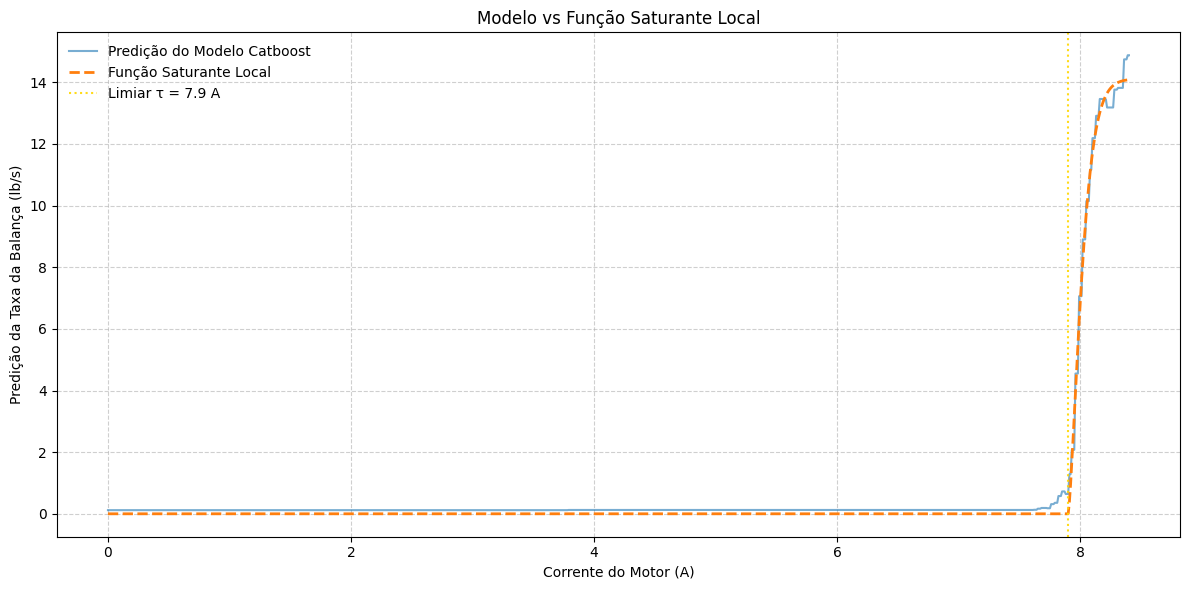

Função ajustada (x em A, y em lb/s):
y(x) = 0, se x ≤ 7.9
y(x) = 14.11 * (1 - exp(-16.7834 * (x - 7.9)^1.40)), se x > 7.9


In [88]:
# 8.4 Função saturante Local

# 1) Simulação da região inicial (0 a 8,4 A)
x = np.arange(0, 8.41, 0.01)
X_sim = pd.DataFrame({"corrente_do_motor": x})
y_model = gs.predict(X_sim)

# 2) Definição do limiar τ
tau = 7.9  # limiar físico (em A)

# 3) Ajuste dos parâmetros A, k e p usando a função auxiliar sat_with_exponent (definida no tópico 2.3)
mask_fit = x > tau
x_fit = x[mask_fit]
y_fit = y_model[mask_fit]

# Chutes iniciais
A0 = np.nanpercentile(y_fit, 95) if len(y_fit) else 8000.0
k0, p0 = 0.05, 0.8

# Ajuste com restrições
popt, _ = curve_fit(
    lambda xv, A, k, p: sat_with_exponent(xv, A, k, p, tau),
    x_fit, y_fit, p0=[A0, k0, p0],
    bounds=([0, 0, 0.1], [np.inf, np.inf, 2.0]),
    maxfev=20000
)
A_hat, k_hat, p_hat = popt

# 4) Predição da função ajustada
y_fun = sat_with_exponent(x, A_hat, k_hat, p_hat, tau)

# 5) Comparação gráfica
plt.figure(figsize=(12, 6))
plt.plot(x, y_model, alpha=0.6, label="Predição do Modelo Catboost")
plt.plot(x, y_fun, linestyle="--", linewidth=2,
         label=f"Função Saturante Local")
plt.axvline(tau, color="gold", linestyle=":", alpha=0.9,
            label=f"Limiar τ = {tau:.1f} A")

plt.xlabel("Corrente do Motor (A)")
plt.ylabel("Predição da Taxa da Balança (lb/s)")
plt.title("Modelo vs Função Saturante Local")

# Legenda no canto superior esquerdo para evitar sobreposição
plt.legend(loc="upper left", frameon=False)

plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# 6) Exibir fórmula final
print("Função ajustada (x em A, y em lb/s):")
print(f"y(x) = 0, se x ≤ {tau:.1f}")
print(f"y(x) = {A_hat:.2f} * (1 - exp(-{k_hat:.4f} * (x - {tau:.1f})^{p_hat:.2f})), se x > {tau:.1f}")


### 8.5 Construção da curva híbrida

Nos tópicos anteriores, vimos que:  
- A curva ajustada pela função global não representava bem a **subida inicial** (7,9 A a 8,4 A).  
- O ajuste local capturou melhor esse comportamento inicial, mas não era adequado para toda a faixa.  

Diante disso, foi criada uma **curva híbrida**, que combina os dois ajustes:  
- **Ajuste Local (7,9 A até 8,4 A):** descreve com maior precisão o início da curva após o limiar.  
- **Ajuste Global (8,4 A até 30 A):** aplicado somente após o término do ajuste local, representando a tendência geral e a saturação em correntes maiores.  

Essa curva híbrida **não foi definida arbitrariamente**: ela foi construída a partir das **predições do modelo selecionado (CatBoost)**, servindo como uma representação funcional aproximada da relação aprendida.  

#### **Interpretação**  
A função híbrida proporciona uma **maior clareza na interpretação**, ao unir as duas curvas em uma formulação bem definida:  
- Uma **subida inicial mais íngreme** (capturada pelo ajuste local).  
- Uma **tendência de saturação gradual** (capturada pelo ajuste global).  

O gráfico mostra que a curva híbrida ficou muito próxima da predição feita pelo modelo.

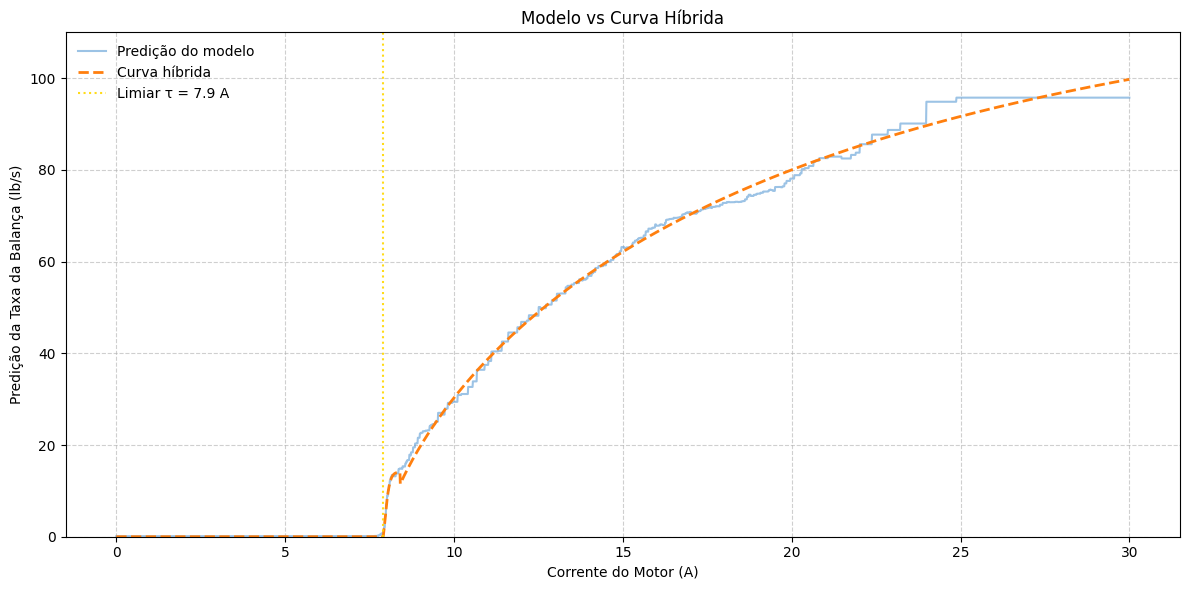

Função Híbrida Ajustada (x em A, y em lb/s):
f(x) = 0, se x ≤ 7.9
f(x) = 14.11 * (1 - exp(-16.7835 * (x - 7.9)^1.40)), se 7.9 < x ≤ 8.4
f(x) = 124.90 * (1 - exp(-0.1599 * (x - 7.9)^0.74)), se x > 8.4


In [89]:
# 8.5 Curva Híbrida: Local (até 8,4 A) + Global (até 30 A)

# 1) Simulação do intervalo de interesse
x = np.arange(0, 30.01, 0.01)
X_sim = pd.DataFrame({"corrente_do_motor": x})
y_model = gs.predict(X_sim)

# 2) Definição dos limites
tau = 7.9      # corrente a partir da qual há transporte efetivo
cutoff = 8.4   # ponto de transição entre ajuste local e global

# 3) Ajuste LOCAL (7,9 A até 8,4 A)
mask_fit_loc = (x > tau) & (x <= cutoff)
x_fit_loc, y_fit_loc = x[mask_fit_loc], y_model[mask_fit_loc]

popt_loc, _ = curve_fit(
    lambda xv, A, k, p: sat_with_exponent(xv, A, k, p, tau),
    x_fit_loc, y_fit_loc,
    p0=[2000, 1.0, 2.0],
    bounds=([0, 0, 0.1], [np.inf, np.inf, 3.0]),
    maxfev=20000
)

A_loc, k_loc, p_loc = popt_loc

# 4) Ajuste GLOBAL (acima de 8,4 A até 30 A)
mask_fit_glob = x > cutoff
x_fit_glob, y_fit_glob = x[mask_fit_glob], y_model[mask_fit_glob]

popt_glob, _ = curve_fit(
    lambda xv, A, k, p: sat_with_exponent(xv, A, k, p, tau),
    x_fit_glob, y_fit_glob,
    p0=[13000, 0.05, 1.0],
    bounds=([0, 0, 0.1], [np.inf, np.inf, 2.0]),
    maxfev=20000
)

A_glob, k_glob, p_glob = popt_glob

# 5) Construção da curva híbrida
y_hybrid = np.zeros_like(x, dtype=float)

mask_local = (x > tau) & (x <= cutoff)
mask_global = x > cutoff

y_hybrid[mask_local] = sat_with_exponent(x[mask_local], A_loc, k_loc, p_loc, tau)
y_hybrid[mask_global] = sat_with_exponent(x[mask_global], A_glob, k_glob, p_glob, tau)

# 6) Comparação gráfica
plt.figure(figsize=(12, 6))

plt.plot(x, y_model, alpha=0.6, label="Predição do modelo", color="#5B9BD5")
plt.plot(x, y_hybrid, linestyle="--", linewidth=2, color="tab:orange", label="Curva híbrida")

plt.axvline(tau, color="gold", linestyle=":", alpha=0.9, label=f"Limiar τ = {tau:.1f} A")

plt.xlabel("Corrente do Motor (A)")
plt.ylabel("Predição da Taxa da Balança (lb/s)")
plt.title("Modelo vs Curva Híbrida")

plt.ylim(0, 110)

plt.legend(loc="upper left", frameon=False)
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

# 7) Fórmula final da função híbrida
print("Função Híbrida Ajustada (x em A, y em lb/s):")
print(f"f(x) = 0, se x ≤ {tau:.1f}")
print(f"f(x) = {A_loc:.2f} * (1 - exp(-{k_loc:.4f} * (x - {tau:.1f})^{p_loc:.2f})), se {tau:.1f} < x ≤ {cutoff:.1f}")
print(f"f(x) = {A_glob:.2f} * (1 - exp(-{k_glob:.4f} * (x - {tau:.1f})^{p_glob:.2f})), se x > {cutoff:.1f}")

## 8.6 Validação prática da função híbrida

Para verificar a aplicabilidade da função híbrida, a equação ajustada foi aplicada diretamente sobre os dados reais de **corrente do motor** no conjunto holdout.

O objetivo é comparar visualmente três referências:

- **Taxa da Balança real:** valores registrados no dataset.
- **Predição do modelo:** valores estimados pelo modelo selecionado.
- **Função híbrida:** aproximação matemática gerada a partir das curvas saturantes local e global.

Essa validação permite verificar se a função híbrida mantém comportamento próximo ao modelo treinado, mesmo sendo uma representação matemática simplificada da relação entre corrente do motor e taxa da balança.

### **Interpretação**

O gráfico mostra que a função híbrida acompanha de forma próxima a predição do modelo selecionado, principalmente nas variações principais da taxa ao longo do holdout.

Mesmo sendo uma representação matemática simplificada, a função híbrida preserva o comportamento geral aprendido pelo modelo, indicando que a relação entre corrente do motor e taxa da balança pode ser aproximada por uma formulação interpretável.

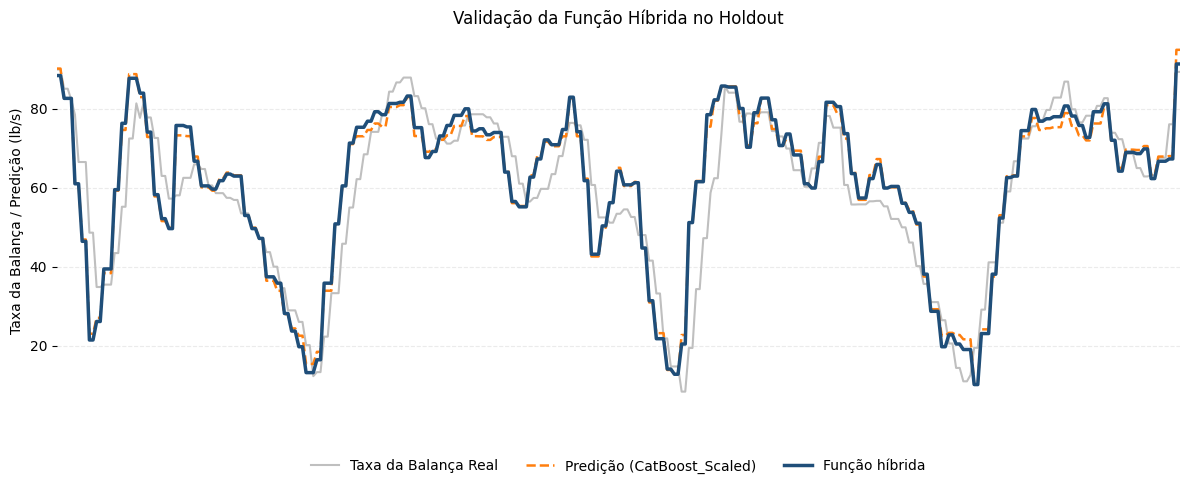

In [90]:
# 8.6 Validação prática da função híbrida

# Aplicar a função híbrida sobre os dados reais de corrente do holdout
x_holdout = X_holdout["corrente_do_motor"].values

y_hybrid_holdout = np.zeros_like(x_holdout, dtype=float)

mask_local = (x_holdout > tau) & (x_holdout <= cutoff)
mask_global = x_holdout > cutoff

y_hybrid_holdout[mask_local] = sat_with_exponent(
    x_holdout[mask_local], A_loc, k_loc, p_loc, tau
)

y_hybrid_holdout[mask_global] = sat_with_exponent(
    x_holdout[mask_global], A_glob, k_glob, p_glob, tau
)

# Selecionar apenas parte do holdout para melhor visualização
n_plot = len(y_holdout) // 4

y_real_plot = y_holdout.iloc[:n_plot]
y_model_plot = y_pred_holdout[:n_plot]
y_hybrid_plot = y_hybrid_holdout[:n_plot]

# Gráfico de validação
plt.figure(figsize=(12, 5))
ax1 = plt.gca()

ax1.plot(
    y_real_plot.index,
    y_real_plot.values,
    color="#BFBFBF",
    linewidth=1.5,
    label="Taxa da Balança Real"
)

ax1.plot(
    y_real_plot.index,
    y_model_plot,
    color="tab:orange",
    linewidth=1.8,
    linestyle="--",
    label=f"Predição ({best_model_name})"
)

ax1.plot(
    y_real_plot.index,
    y_hybrid_plot,
    color="#1F4E79",
    linewidth=2.5,
    label="Função híbrida"
)

# Remover margens laterais
ax1.margins(x=0)

# Remover bordas do gráfico
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.spines["left"].set_visible(False)
ax1.spines["bottom"].set_visible(False)

ax1.set_xlabel("")
ax1.set_xticks([])
ax1.set_ylabel("Taxa da Balança / Predição (lb/s)")

plt.title("Validação da Função Híbrida no Holdout")

plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.1),
    ncol=3,
    frameon=False
)

plt.grid(True, linestyle="--", alpha=0.25)

plt.tight_layout()
plt.show()

# 9. Conclusão

O objetivo deste trabalho foi avaliar a viabilidade da predição da taxa de material transportado a partir da corrente elétrica de um motor, utilizando dados reais de um transportador de grãos e tendo a balança como referência para validação. Para isso, foram avaliados diferentes modelos de regressão, desde o DummyRegressor (baseline) até algoritmos de machine learning mais sofisticados.

Os resultados demonstraram que existe uma relação consistente entre a corrente do motor e a taxa de material transportado, permitindo realizar estimativas com bom nível de precisão a partir de uma única variável de entrada.

Entre os modelos avaliados, o CatBoost apresentou o melhor desempenho, alcançando resultados consistentes nas métricas MAE, RMSE e R², além de baixo desvio-padrão entre os folds da validação cruzada, indicando estabilidade e boa capacidade de generalização.

Na validação cruzada, o modelo atingiu R² médio de 0.96 ± 0.0167, demonstrando consistência entre os folds e forte aderência aos dados utilizados no treinamento.

Além da etapa de modelagem, também foi desenvolvida uma representação matemática baseada nas previsões do modelo, utilizando funções saturantes locais e globais para aproximar o comportamento aprendido.

A função híbrida apresentou comportamento próximo ao modelo treinado durante a validação no holdout, demonstrando que a relação entre corrente e taxa pode ser representada de forma simplificada, interpretável e com boa aderência ao comportamento observado nos dados reais.

### Observações

- Modelos como Gradient Boosting e LightGBM também apresentaram bom desempenho, embora ligeiramente inferiores ao CatBoost.
- A utilização apenas da corrente do motor como variável de entrada já foi suficiente para capturar grande parte do comportamento da taxa de grãos transportado.
- A função híbrida construída a partir das previsões do modelo demonstrou potencial como alternativa para aplicações que demandem uma representação matemática mais leve e de fácil implementação.

De forma geral, o estudo demonstrou que a corrente elétrica do motor de um transportador pode ser utilizada como alternativa para estimar a taxa de material transportado em cenários onde a instalação de balanças seja inviável ou limitada, servindo como alternativa em aplicações com restrições de instrumentação, custo ou medição direta.